In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path
import pandas as pd

In [4]:
root_dir = Path(r"Z:\Bel\Farid_bel\Old_Experiment_Outputs")
# Find all CSV files recursively
csv_files = list(root_dir.rglob("*.csv"))

if not csv_files:
    print("No CSV files found.")
else:
    dfs = []
    
    for f in csv_files:
        if "analysis" in str(f):
            try:
                df = pd.read_csv(f)
                df["source_file"] = str(f)          # optional: keep track of original file
                df["source_folder"] = str(f.parent) # optional
                dfs.append(df)
                print(f"Loaded: {f}")
            except Exception as e:
                print(f"Failed to read {f}: {e}")

    if dfs:
        combined = pd.concat(dfs, ignore_index=True, sort=False)
        
        output_file = root_dir / "all_csvs_concatenated.csv"
        combined.to_csv(output_file, index=False)
        
        print(f"\nSaved concatenated CSV to:\n{output_file}")
        print(f"Total files combined: {len(dfs)}")
        print(f"Combined shape: {combined.shape}")
    else:
        print("No CSV files could be read successfully.")

Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 flow 6million day 7_img0_valve 1\03.10.25 flow 6million day 7_img0_valve 1_analysis_metrics.csv
Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 flow 6million day 7_img1_valve 2\03.10.25 flow 6million day 7_img1_valve 2_analysis_metrics.csv
Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 flow 6million day 7_img2_valve 4\03.10.25 flow 6million day 7_img2_valve 4_analysis_metrics.csv
Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 flow 6million day 7_img3_valve 5\03.10.25 flow 6million day 7_img3_valve 5_analysis_metrics.csv
Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 flow 6million day 7_img4_valve 8\03.10.25 flow 6million day 7_img4_valve 8_analysis_metrics.csv
Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 static 6million day 7_img0_static 1\03.10.25 static 6million day 7_img0_static 1_analysis_metrics.csv
Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 static 6million day

In [5]:
combined["image_name"].unique()

array(['03.10.25 flow 6million day 7_img0_valve 1',
       '03.10.25 flow 6million day 7_img1_valve 2',
       '03.10.25 flow 6million day 7_img2_valve 4',
       '03.10.25 flow 6million day 7_img3_valve 5',
       '03.10.25 flow 6million day 7_img4_valve 8',
       '03.10.25 static 6million day 7_img0_static 1',
       '03.10.25 static 6million day 7_img1_static 2',
       '03.10.25 static 6million day 7_img2_static 3',
       '03.10.25 static 6million day 7_img4_static 5',
       '03.10.25 static 6million day 7_img5_static 6',
       '03.10.25 static 6million day 7_img6_static 7',
       '03.10.25 static 6million day 7_img7_static 8',
       '18.09.25 flow 6million day 7_img0_Valve 1',
       '18.09.25 flow 6million day 7_img1_Valve 2',
       '18.09.25 flow 6million day 7_img2_Valve 3',
       '03.10.25 static 6million day 7_img3_static 4',
       '18.09.25 flow 6million day 7_img3_Valve 4',
       '30.10.25 flow 6million day 7_img0_Valve 1',
       '30.10.25 flow 6million day 7_img

In [6]:
def find_condition(row):
    name = str(row["image_name"]).lower()
    if "static" in name:
        return "static"
    elif "flow" in name:
        return "flow"
    # elif "reservoir" in name:
    #     return "resevoir"
    # elif any(f"valve {n}" in name for n in [1, 2, 7, 8]):
    #     return "high_flow"
    # elif any(f"valve {n}" in name for n in [3, 4, 5, 6]):
    #     return "low_flow"
    else:
        return "NA"
    # return row
        

In [7]:
combined["experiment"] = combined.apply(find_condition, axis=1)

In [8]:
combined[combined["experiment"]== "flow"]

,image_name,source_file,image_index,chip_volume_um3,convex_hull_volume_um3,vessel_volume_um3,vessel_volume_fraction,total_vessel_length_um,vessel_length_per_chip_volume_um_inverse2,sprouts_per_vessel_length_um_inverse,...,internal_pore_area_fraction_in_filled_vascular_area,median_internal_pore_area_um2,p90_minus_p10_internal_pore_area_um2,median_internal_pore_max_inscribed_radius_um,p90_minus_p10_internal_pore_max_inscribed_radius_um,sprouts_per_chip_volume_um_inverse3,junctions_per_chip_volume_um_inverse3,total_internal_pore_density_per_vessel_volume_um_inverse3,source_folder,experiment
0,03.10.25 flow 6million day 7_img0_valve 1,Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10....,0,2.691953e+09,2.639157e+09,1.699178e+09,0.643834,638196.781555,0.000242,0.001018,...,0.286809,2504.0,20540.0,20.880613,44.159745,2.462908e-07,0.000001,0.000022,Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10....,flow
1,03.10.25 flow 6million day 7_img1_valve 2,Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10....,1,2.406768e+09,2.356279e+09,1.511864e+09,0.641632,568024.718153,0.000241,0.000889,...,0.283683,2968.0,20844.8,22.803509,46.287230,2.143209e-07,0.000001,0.000022,Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10....,flow
2,03.10.25 flow 6million day 7_img2_valve 4,Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10....,2,2.442247e+09,2.391451e+09,1.538070e+09,0.643153,598654.941236,0.000250,0.000758,...,0.309536,3380.0,26888.0,24.738634,50.821765,1.898429e-07,0.000001,0.000021,Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10....,flow
3,03.10.25 flow 6million day 7_img3_valve 5,Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10....,3,2.537264e+09,2.485337e+09,1.500969e+09,0.603930,632661.865121,0.000255,0.000771,...,0.312647,3096.0,23969.6,23.323808,46.640546,1.963517e-07,0.000001,0.000024,Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10....,flow
4,03.10.25 flow 6million day 7_img4_valve 8,Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10....,4,3.137820e+09,3.086639e+09,1.404309e+09,0.454964,646108.090425,0.000209,0.001001,...,0.345472,2760.0,24004.0,22.000000,47.961354,2.096131e-07,0.000001,0.000022,Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10....,flow
12,18.09.25 flow 6million day 7_img0_Valve 1,Z:\Bel\Farid_bel\Old_Experiment_Outputs\18.09....,0,2.223222e+09,2.172537e+09,1.325901e+09,0.610301,564721.965612,0.000260,0.001002,...,0.260635,1820.0,18212.0,17.888544,40.386603,2.605249e-07,0.000002,0.000025,Z:\Bel\Farid_bel\Old_Experiment_Outputs\18.09....,flow
13,18.09.25 flow 6million day 7_img1_Valve 2,Z:\Bel\Farid_bel\Old_Experiment_Outputs\18.09....,1,1.337942e+09,1.288914e+09,7.622559e+08,0.591394,441198.869704,0.000342,0.000748,...,0.333504,1952.0,19088.8,18.439089,38.045431,2.560295e-07,0.000002,0.000025,Z:\Bel\Farid_bel\Old_Experiment_Outputs\18.09....,flow
14,18.09.25 flow 6million day 7_img2_Valve 3,Z:\Bel\Farid_bel\Old_Experiment_Outputs\18.09....,2,1.803708e+09,1.754221e+09,9.730848e+08,0.554710,464567.065898,0.000265,0.000960,...,0.349208,2800.0,25622.0,22.360680,50.060182,2.542438e-07,0.000001,0.000021,Z:\Bel\Farid_bel\Old_Experiment_Outputs\18.09....,flow
16,18.09.25 flow 6million day 7_img3_Valve 4,Z:\Bel\Farid_bel\Old_Experiment_Outputs\18.09....,3,2.222392e+09,2.170734e+09,6.621151e+08,0.305019,400256.563057,0.000184,0.001269,...,0.318287,2124.0,31251.2,19.697716,55.694592,2.340223e-07,0.000001,0.000015,Z:\Bel\Farid_bel\Old_Experiment_Outputs\18.09....,flow
17,30.10.25 flow 6million day 7_img0_Valve 1,Z:\Bel\Farid_bel\Old_Experiment_Outputs\30.10....,0,2.235454e+09,2.184440e+09,1.315683e+09,0.602298,605181.337972,0.000277,0.000737,...,0.312010,2540.0,22723.2,20.880613,45.628277,2.041714e-07,0.000002,0.000025,Z:\Bel\Farid_bel\Old_Experiment_Outputs\30.10....,flow


In [9]:
# combined["experiment"] = combined["image_name"].astype(str).str.contains("flow", case=False, na=False).map({True: "flow", False: "static"})

# combined = combined[combined["image_name"].astype(str).str.contains("6million day 7", case=False, na=False)]
# combined.head()

In [10]:
combined[combined["experiment"]=="resevoir"]

,image_name,source_file,image_index,chip_volume_um3,convex_hull_volume_um3,vessel_volume_um3,vessel_volume_fraction,total_vessel_length_um,vessel_length_per_chip_volume_um_inverse2,sprouts_per_vessel_length_um_inverse,...,internal_pore_area_fraction_in_filled_vascular_area,median_internal_pore_area_um2,p90_minus_p10_internal_pore_area_um2,median_internal_pore_max_inscribed_radius_um,p90_minus_p10_internal_pore_max_inscribed_radius_um,sprouts_per_chip_volume_um_inverse3,junctions_per_chip_volume_um_inverse3,total_internal_pore_density_per_vessel_volume_um_inverse3,source_folder,experiment


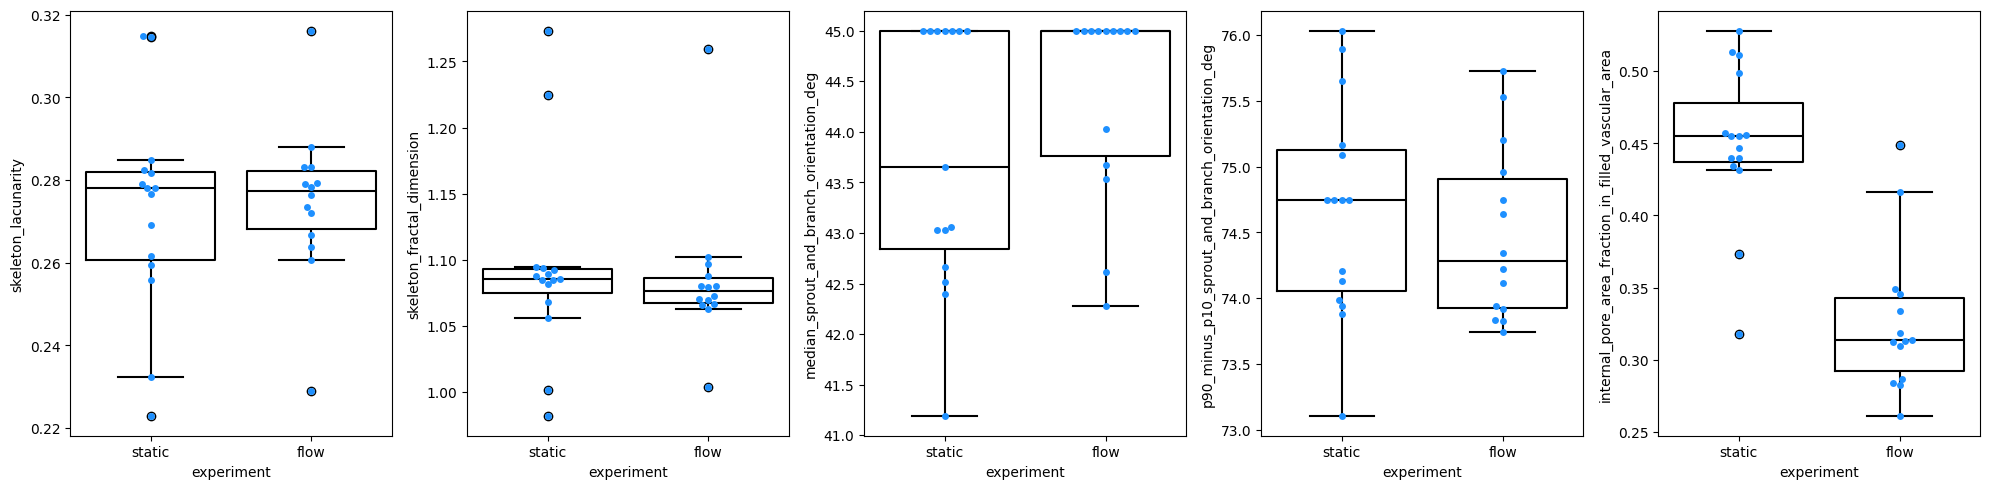

In [11]:
fig, ax = plt.subplots(ncols = 5, figsize=(20,5))
# xorder = ["static", "resevoir", "low_flow", "high_flow"]
xorder = ["static", "flow"]
sns.swarmplot(data = combined, x="experiment", y="skeleton_lacunarity", ax=ax[0], zorder=100, color="dodgerblue", order=xorder)
sns.boxplot(data = combined, x="experiment", y="skeleton_lacunarity", ax=ax[0], fill=False, color="#000000", order=xorder)

sns.swarmplot(data = combined, x="experiment", y="skeleton_fractal_dimension", ax=ax[1], zorder=100, color="dodgerblue", order=xorder)
sns.boxplot(data = combined, x="experiment", y="skeleton_fractal_dimension", ax=ax[1], fill=False, color="#000000", order=xorder)

sns.swarmplot(data = combined, x="experiment", y="median_sprout_and_branch_orientation_deg", ax=ax[2], zorder=100, color="dodgerblue", order=xorder)
sns.boxplot(data = combined, x="experiment", y="median_sprout_and_branch_orientation_deg", ax=ax[2], fill=False, color="#000000", order=xorder)

sns.swarmplot(data = combined, x="experiment", y="p90_minus_p10_sprout_and_branch_orientation_deg", ax=ax[3], zorder=100, color="dodgerblue", order=xorder)
sns.boxplot(data = combined, x="experiment", y="p90_minus_p10_sprout_and_branch_orientation_deg", ax=ax[3], fill=False, color="#000000", order=xorder)

sns.swarmplot(data = combined, x="experiment", y="internal_pore_area_fraction_in_filled_vascular_area", ax=ax[4], zorder=100, color="dodgerblue", order=xorder)
sns.boxplot(data = combined, x="experiment", y="internal_pore_area_fraction_in_filled_vascular_area", ax=ax[4], fill=False, color="#000000", order=xorder)

plt.tight_layout()

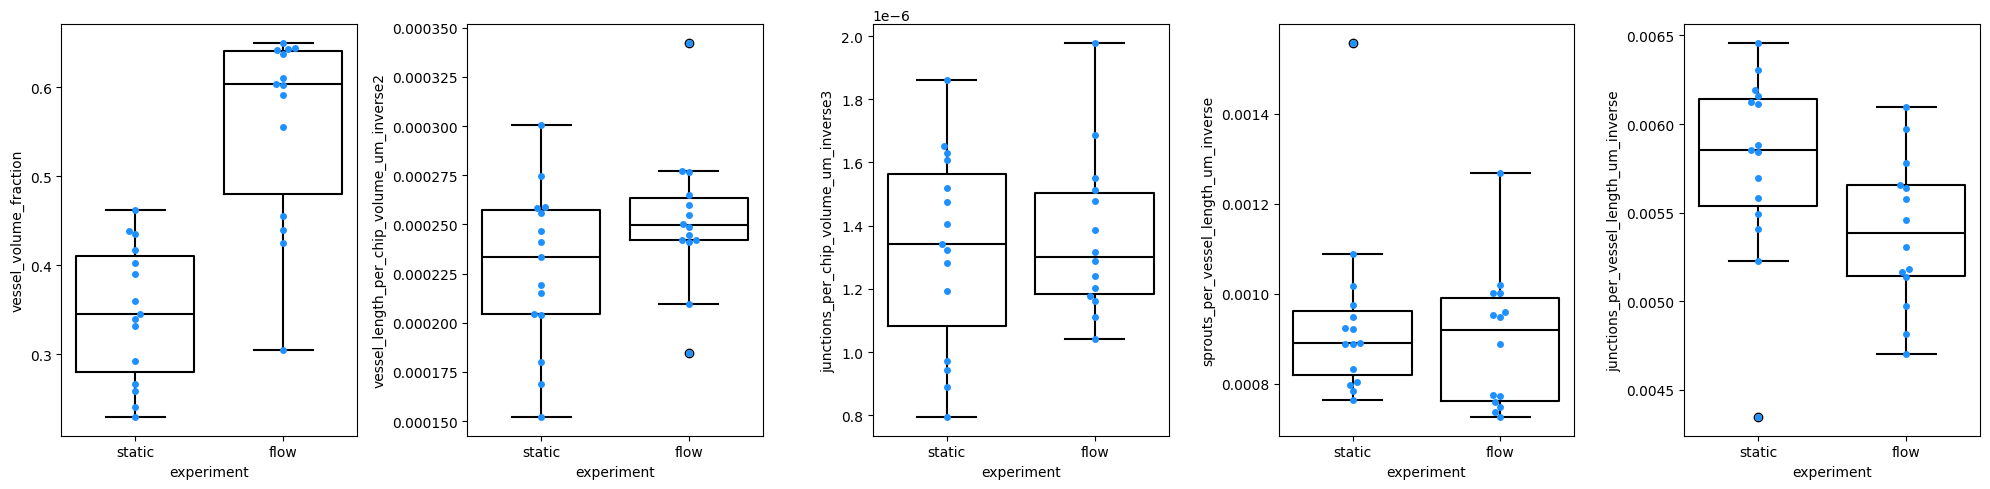

In [12]:
fig, ax = plt.subplots(ncols = 5, figsize=(20,5))
sns.swarmplot(data = combined, x="experiment", y="vessel_volume_fraction", ax=ax[0], zorder=100, color="dodgerblue", order = xorder)
sns.boxplot(data = combined, x="experiment", y="vessel_volume_fraction", ax=ax[0], fill=False, color="#000000", order = xorder)

sns.swarmplot(data = combined, x="experiment", y="vessel_length_per_chip_volume_um_inverse2", ax=ax[1], zorder=100, color="dodgerblue", order = xorder)
sns.boxplot(data = combined, x="experiment", y="vessel_length_per_chip_volume_um_inverse2", ax=ax[1], fill=False, color="#000000", order = xorder)

sns.swarmplot(data = combined, x="experiment", y="junctions_per_chip_volume_um_inverse3", ax=ax[2], zorder=100, color="dodgerblue", order = xorder)
sns.boxplot(data = combined, x="experiment", y="junctions_per_chip_volume_um_inverse3", ax=ax[2], fill=False, color="#000000", order = xorder)

sns.swarmplot(data = combined, x="experiment", y="sprouts_per_vessel_length_um_inverse", ax=ax[3], zorder=100, color="dodgerblue", order = xorder)
sns.boxplot(data = combined, x="experiment", y="sprouts_per_vessel_length_um_inverse", ax=ax[3], fill=False, color="#000000", order = xorder)

sns.swarmplot(data = combined, x="experiment", y="junctions_per_vessel_length_um_inverse", ax=ax[4], zorder=100, color="dodgerblue", order = xorder)
sns.boxplot(data = combined, x="experiment", y="junctions_per_vessel_length_um_inverse", ax=ax[4], fill=False, color="#000000", order = xorder)

plt.tight_layout()

In [13]:
combined.columns

Index(['image_name', 'source_file', 'image_index', 'chip_volume_um3',
       'convex_hull_volume_um3', 'vessel_volume_um3', 'vessel_volume_fraction',
       'total_vessel_length_um', 'vessel_length_per_chip_volume_um_inverse2',
       'sprouts_per_vessel_length_um_inverse',
       'junctions_per_vessel_length_um_inverse', 'skeleton_fractal_dimension',
       'skeleton_lacunarity', 'median_sprout_and_branch_orientation_deg',
       'p90_minus_p10_sprout_and_branch_orientation_deg',
       'median_sprout_and_branch_median_cs_area_um2',
       'p90_minus_p10_sprout_and_branch_median_cs_area_um2',
       'median_junction_dist_nearest_junction_um',
       'p90_minus_p10_junction_dist_nearest_junction_um',
       'median_sprout_dist_nearest_endpoint_um',
       'p90_minus_p10_sprout_dist_nearest_endpoint_um',
       'average_vessel_volume_um3', 'total_internal_pore_count',
       'internal_pore_area_fraction_in_filled_vascular_area',
       'median_internal_pore_area_um2', 'p90_minus_p10_int

In [18]:
root_dir = Path(r"Z:\Bel\Farid_bel\Old_Experiment_Outputs")
# Find all CSV files recursively
csv_files = list(root_dir.rglob("*.csv"))

if not csv_files:
    print("No CSV files found.")
else:
    dfs = []
    
    for f in csv_files:
        if "branch" in str(f):
            try:
                df = pd.read_csv(f)
                df["source_file"] = str(f)          # optional: keep track of original file
                df["source_folder"] = str(f.parent) # optional
                dfs.append(df)
                print(f"Loaded: {f}")
            except Exception as e:
                print(f"Failed to read {f}: {e}")

    if dfs:
        combined = pd.concat(dfs, ignore_index=True, sort=False)
        
        output_file = root_dir / "all_branch_csvs_concatenated.csv"
        combined.to_csv(output_file, index=False)
        
        print(f"\nSaved concatenated CSV to:\n{output_file}")
        print(f"Total files combined: {len(dfs)}")
        print(f"Combined shape: {combined.shape}")
    else:
        print("No CSV files could be read successfully.")

Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\all_branch_csvs_concatenated.csv
Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 flow 6million day 7_img0_valve 1\03.10.25 flow 6million day 7_img0_valve 1_branch_metrics.csv
Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 flow 6million day 7_img1_valve 2\03.10.25 flow 6million day 7_img1_valve 2_branch_metrics.csv
Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 flow 6million day 7_img2_valve 4\03.10.25 flow 6million day 7_img2_valve 4_branch_metrics.csv
Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 flow 6million day 7_img3_valve 5\03.10.25 flow 6million day 7_img3_valve 5_branch_metrics.csv
Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 flow 6million day 7_img4_valve 8\03.10.25 flow 6million day 7_img4_valve 8_branch_metrics.csv
Loaded: Z:\Bel\Farid_bel\Old_Experiment_Outputs\03.10.25 static 6million day 7_img0_static 1\03.10.25 static 6million day 7_img0_static 1_branch_metrics.csv
Loaded:

In [19]:
combined["experiment"] = combined.apply(find_condition, axis=1)
combined.columns

Index(['image_name', 'source_file', 'image_index', 'node_start', 'node_end',
       'is_sprout', 'start_z', 'start_y', 'start_x', 'end_z', 'end_y', 'end_x',
       'start_z_um', 'start_y_um', 'start_x_um', 'end_z_um', 'end_y_um',
       'end_x_um', 'path_length_um', 'endpoint_distance_um',
       'mean_cs_area_um2', 'median_cs_area_um2', 'std_cs_area_um2',
       'mean_width_um', 'median_width_um', 'branch_volume_um3',
       'orientation_to_device_axis_deg', 'source_folder', 'experiment'],
      dtype='object')

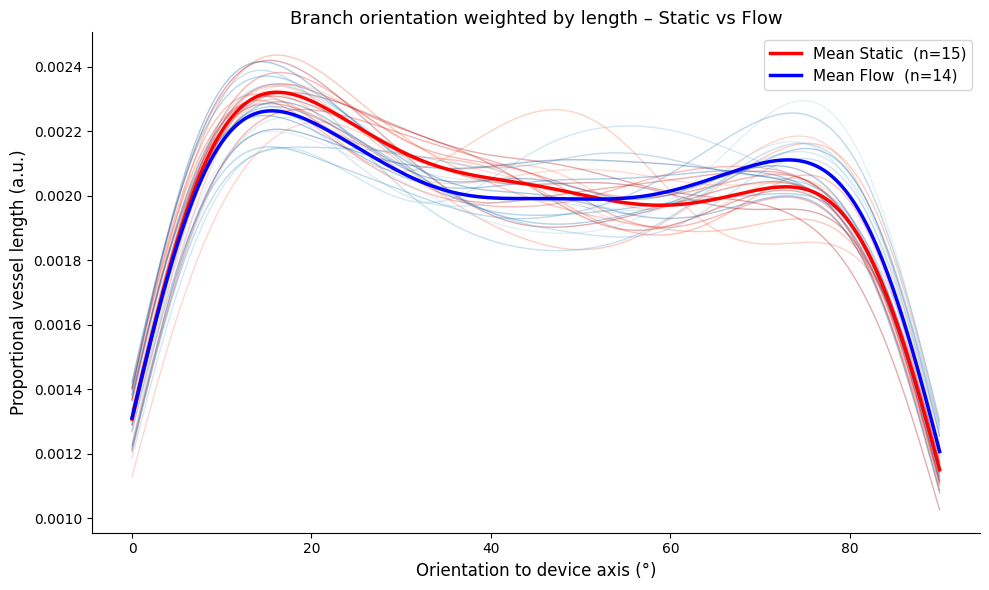

In [23]:
from scipy.stats import gaussian_kde

# Filter to valid data
plot_df = combined.dropna(subset=["orientation_to_device_axis_deg", "path_length_um"]).copy()
plot_df = plot_df[plot_df["experiment"].isin(["static", "flow"])]

# Shared x-axis for evaluation
x_eval = np.linspace(plot_df["orientation_to_device_axis_deg"].min(),
                      plot_df["orientation_to_device_axis_deg"].max(), 500)

# Colour maps: shades of red for static, shades of blue for flow
from matplotlib.cm import Reds, Blues

static_images = sorted(plot_df[plot_df["experiment"] == "static"]["image_name"].unique())
flow_images   = sorted(plot_df[plot_df["experiment"] == "flow"]["image_name"].unique())

static_colors = [Reds(0.3 + 0.6 * i / max(len(static_images) - 1, 1)) for i in range(len(static_images))]
flow_colors   = [Blues(0.3 + 0.6 * i / max(len(flow_images) - 1, 1))   for i in range(len(flow_images))]

fig, ax = plt.subplots(figsize=(10, 6))

# Store KDE values for computing the mean curve
static_kdes = []
flow_kdes   = []

# --- Per-image length-weighted KDE ---
for img_name, color in zip(static_images, static_colors):
    sub = plot_df[plot_df["image_name"] == img_name]
    angles  = sub["orientation_to_device_axis_deg"].values
    lengths = sub["path_length_um"].values
    weights = lengths / lengths.sum()          # normalise weights
    kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
    y = kde(x_eval)
    y = y / y.sum()                            # normalise area so curves are comparable
    ax.plot(x_eval, y, color=color, alpha=0.35, linewidth=1)
    static_kdes.append(y)

for img_name, color in zip(flow_images, flow_colors):
    sub = plot_df[plot_df["image_name"] == img_name]
    angles  = sub["orientation_to_device_axis_deg"].values
    lengths = sub["path_length_um"].values
    weights = lengths / lengths.sum()
    kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
    y = kde(x_eval)
    y = y / y.sum()
    ax.plot(x_eval, y, color=color, alpha=0.35, linewidth=1)
    flow_kdes.append(y)

# --- Mean curves ---
mean_static = np.mean(static_kdes, axis=0)
mean_flow   = np.mean(flow_kdes, axis=0)

ax.plot(x_eval, mean_static, color="red",  linewidth=2.5, label=f"Mean Static  (n={len(static_images)})")
ax.plot(x_eval, mean_flow,   color="blue", linewidth=2.5, label=f"Mean Flow  (n={len(flow_images)})")

ax.set_xlabel("Orientation to device axis (°)", fontsize=12)
ax.set_ylabel("Proportional vessel length (a.u.)", fontsize=12)
ax.set_title("Branch orientation weighted by length – Static vs Flow", fontsize=13)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

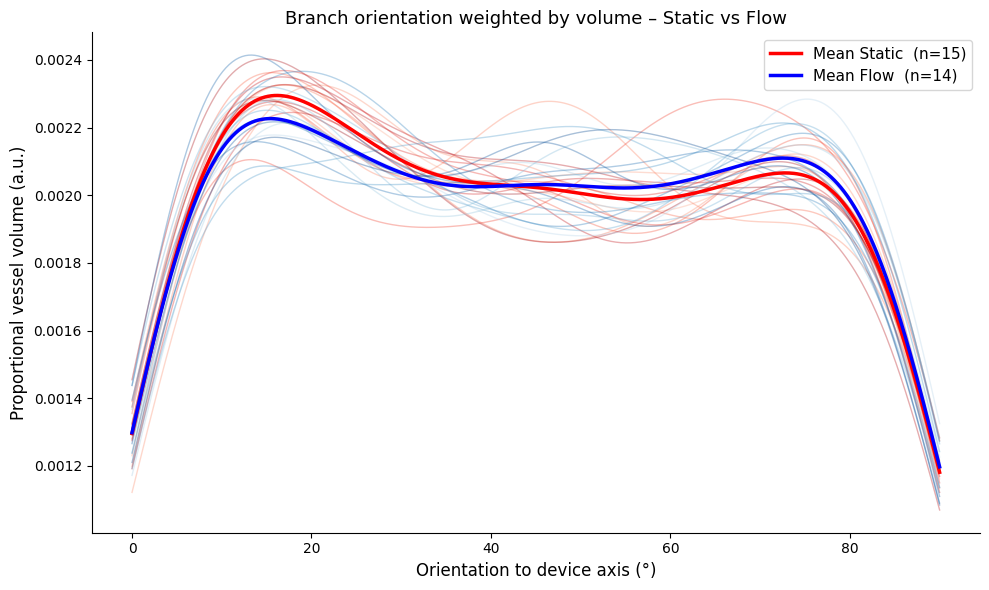

In [24]:
# --- Same plot but weighted by branch VOLUME instead of length ---
vol_df = combined.dropna(subset=["orientation_to_device_axis_deg", "branch_volume_um3"]).copy()
vol_df = vol_df[vol_df["experiment"].isin(["static", "flow"])]

x_eval_v = np.linspace(vol_df["orientation_to_device_axis_deg"].min(),
                        vol_df["orientation_to_device_axis_deg"].max(), 500)

static_images_v = sorted(vol_df[vol_df["experiment"] == "static"]["image_name"].unique())
flow_images_v   = sorted(vol_df[vol_df["experiment"] == "flow"]["image_name"].unique())

static_colors_v = [Reds(0.3 + 0.6 * i / max(len(static_images_v) - 1, 1)) for i in range(len(static_images_v))]
flow_colors_v   = [Blues(0.3 + 0.6 * i / max(len(flow_images_v) - 1, 1))   for i in range(len(flow_images_v))]

fig, ax = plt.subplots(figsize=(10, 6))

static_kdes_v = []
flow_kdes_v   = []

for img_name, color in zip(static_images_v, static_colors_v):
    sub = vol_df[vol_df["image_name"] == img_name]
    angles  = sub["orientation_to_device_axis_deg"].values
    volumes = sub["branch_volume_um3"].values
    weights = volumes / volumes.sum()
    kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
    y = kde(x_eval_v)
    y = y / y.sum()
    ax.plot(x_eval_v, y, color=color, alpha=0.35, linewidth=1)
    static_kdes_v.append(y)

for img_name, color in zip(flow_images_v, flow_colors_v):
    sub = vol_df[vol_df["image_name"] == img_name]
    angles  = sub["orientation_to_device_axis_deg"].values
    volumes = sub["branch_volume_um3"].values
    weights = volumes / volumes.sum()
    kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
    y = kde(x_eval_v)
    y = y / y.sum()
    ax.plot(x_eval_v, y, color=color, alpha=0.35, linewidth=1)
    flow_kdes_v.append(y)

mean_static_v = np.mean(static_kdes_v, axis=0)
mean_flow_v   = np.mean(flow_kdes_v, axis=0)

ax.plot(x_eval_v, mean_static_v, color="red",  linewidth=2.5, label=f"Mean Static  (n={len(static_images_v)})")
ax.plot(x_eval_v, mean_flow_v,   color="blue", linewidth=2.5, label=f"Mean Flow  (n={len(flow_images_v)})")

ax.set_xlabel("Orientation to device axis (°)", fontsize=12)
ax.set_ylabel("Proportional vessel volume (a.u.)", fontsize=12)
ax.set_title("Branch orientation weighted by volume – Static vs Flow", fontsize=13)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()